In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your GitHub repository URL (REPLACE WITH YOUR ACTUAL URL)
REPO_URL = "https://github.com/AleczO/her2-classification.git"
PROJECT_NAME = "her2-classification"

# 3. Clone or Update the repository
%cd /content
if not os.path.exists(PROJECT_NAME):
    print(f"Cloning {PROJECT_NAME}...")
    !git clone {REPO_URL}
else:
    print(f"Repository {PROJECT_NAME} already exists. Pulling latest changes...")
    %cd {PROJECT_NAME}
    !git pull

# 4. Install the project in editable mode
%cd /content/{PROJECT_NAME}
!pip install -e .
!pip install albumentations tqdm matplotlib seaborn

Mounted at /content/drive
/content
Cloning her2-classification...
Cloning into 'her2-classification'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 58 (delta 14), reused 48 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 7.63 MiB | 23.46 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/her2-classification
Obtaining file:///content/her2-classification
  Preparing metadata (setup.py) ... done
  Running setup.py develop for her2-classification


In [3]:
# Cell 2: Unzip Data to Local Storage
import zipfile

# Path to zip file on Google Drive
zip_on_drive = '/content/drive/MyDrive/Projects/HER2/data.zip'
extract_to = '/content/datasets'

if os.path.exists(zip_on_drive):
    print("Extracting dataset to local runtime...")
    with zipfile.ZipFile(zip_on_drive, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Data ready at {extract_to}")
else:
    print("ERROR: data.zip not found on Google Drive! Please check the file path.")

Extracting dataset to local runtime...
Data ready at /content/datasets


In [ ]:
!mv /content/datasets/datasets/Patch-based-dataset/* /content/datasets/

# Cleaning up the empty directories
!rm -rf /content/datasets/datasets

# Final check - should be train_data_patch and test_data_patch 
print("Final check of /content/datasets content:")
!ls /content/datasets

Final check of /content/datasets content:
test_data_patch  train_data_patch


In [5]:
!nvidia-smi

Fri Mar 27 22:02:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!ls /content/her2-classification/src

config.py   __init__.py  __pycache__  utils.py
dataset.py  model.py	 train.py     visualization.py


In [8]:
# Cell 4: Production-ready Training Loop (Fixed save_checkpoint)
import torch
import torch.nn as nn
import torch.optim as optim
import os
import sys

%cd /content/her2-classification
sys.path.append(os.getcwd())

from src import (
    TRAIN_DIR, TEST_DIR,
    HER2Dataset, get_dataloader, get_transforms,
    get_model,
    train_one_epoch, validate,
    save_checkpoint, plot_history,
    config
)

# 1. Settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Starting training session on device: {device}")

# 2. Prepare Data
train_tf = get_transforms(img_size=224, is_train=True)
val_tf = get_transforms(img_size=224, is_train=False)

train_ds = HER2Dataset(TRAIN_DIR, transform=train_tf)
val_ds = HER2Dataset(TEST_DIR, transform=val_tf)

train_loader = get_dataloader(train_ds, batch_size=config.BATCH_SIZE, is_train=True)
val_loader = get_dataloader(val_ds, batch_size=config.BATCH_SIZE, is_train=False)

# 3. Initialize Model, Loss, and Optimizer
model = get_model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# 4. Training Loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
best_val_acc = 0.0

for epoch in range(config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Save History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save logic matched to your GitHub code signature
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }
        # Fixed: Removed 'is_best' and 'checkpoint_dir' to avoid TypeError
        save_checkpoint(checkpoint, filename="best_her2_model.pth")

# 5. Finalize
print("\nTraining complete.")
plot_history(history, filename="her2_training_results.png")

/content/her2-classification
Starting training session on device: cuda

Epoch 1/50


Train Loss: 0.3601 | Train Acc: 86.39%
Val Loss: 0.9006 | Val Acc: 72.23%
Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_her2_model.pth

Epoch 2/50


Train Loss: 0.2532 | Train Acc: 90.49%
Val Loss: 0.2683 | Val Acc: 90.91%
Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_her2_model.pth

Epoch 3/50


Train Loss: 0.2202 | Train Acc: 91.55%
Val Loss: 0.2285 | Val Acc: 91.73%
Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_her2_model.pth

Epoch 4/50


Train Loss: 0.2020 | Train Acc: 92.44%
Val Loss: 0.3993 | Val Acc: 87.91%

Epoch 5/50


...

Train Loss: 0.1164 | Train Acc: 95.45%
Val Loss: 0.1675 | Val Acc: 93.91%

Epoch 28/50


Train Loss: 0.1032 | Train Acc: 96.03%
Val Loss: 0.1930 | Val Acc: 94.05%

Epoch 29/50


Train Loss: 0.1077 | Train Acc: 95.94%
Val Loss: 0.7143 | Val Acc: 82.68%

Epoch 30/50


Train Loss: 0.0933 | Train Acc: 96.36%
Val Loss: 0.2061 | Val Acc: 93.64%

Epoch 31/50


KeyboardInterrupt: 

In [9]:
import os
log_file = "/content/drive/MyDrive/HER2_Output/training_logs_phase1.txt"

with open(log_file, "w") as f:
    f.write("Phase 1: Baseline ResNet50 (LR=0.001)\n")
    f.write("-------------------------------------\n")

    for i in range(len(history['train_acc'])):
        line = f"Epoch {i+1}: Train Acc: {history['train_acc'][i]:.2f}%, Val Acc: {history['val_acc'][i]:.2f}%\n"
        f.write(line)

print(f"Logi zostały pomyślnie wyeksportowane do: {log_file}")

Logi zostały pomyślnie wyeksportowane do: /content/drive/MyDrive/HER2_Output/training_logs_phase1.txt


# Second Phase (Fine-Tuning)

Loading weights from /content/drive/MyDrive/HER2_Output/models/best_model_phase1.pth...
Starting from Baseline Accuracy: 95.50%
Phase 2 started. Target: > 95.50% Val Acc


Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_model_finetuned.pth
Epoch 1/15 - Val Acc: 95.86% [NEW BEST]


Epoch 2/15 - Val Acc: 95.86% 


Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_model_finetuned.pth
Epoch 3/15 - Val Acc: 96.23% [NEW BEST]


Epoch 4/15 - Val Acc: 95.86% 


...

Epoch 11/15 - Val Acc: 96.41% 


Epoch 12/15 - Val Acc: 96.14% 


Epoch 13/15 - Val Acc: 95.86% 


Epoch 14/15 - Val Acc: 95.50% 


Checkpoint saved successfully at: /content/drive/MyDrive/HER2_Output/models/best_model_finetuned.pth
Epoch 15/15 - Val Acc: 96.64% [NEW BEST]
Wykres Seaborn zapisany w: ../results/plots/phase2_training_history.png


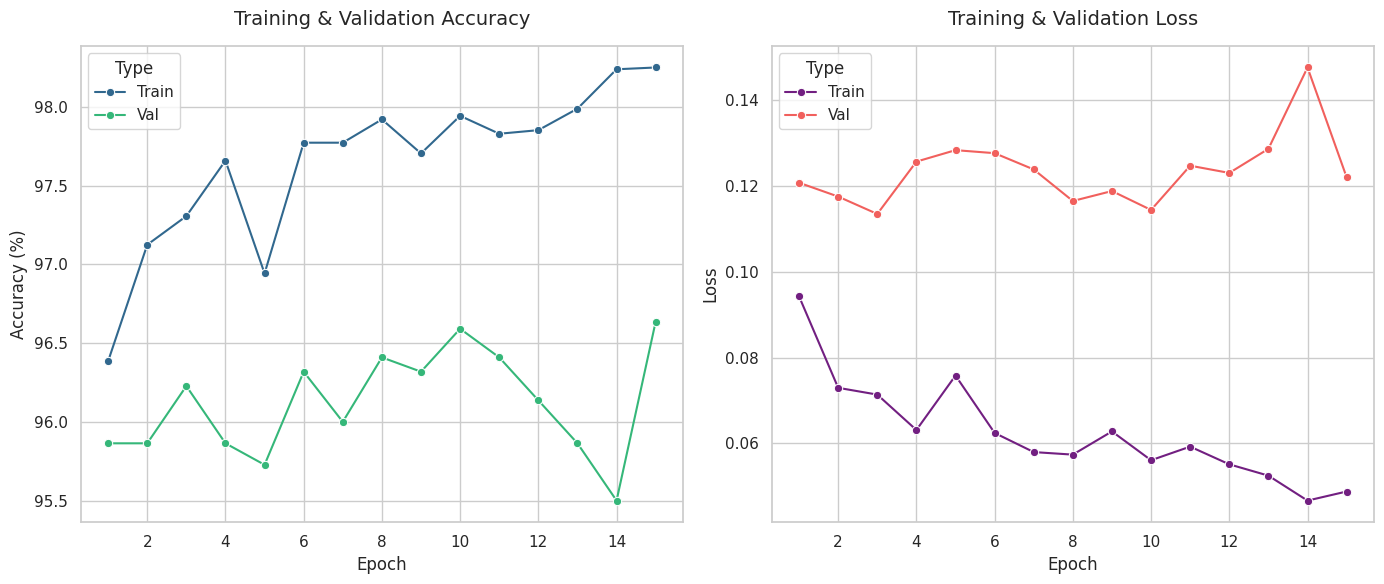

In [17]:
import torch
from torch import nn, optim
import os
import sys

# Ensure src is accessible from notebooks directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src import get_model, HER2Dataset, get_dataloader, get_transforms, config, save_checkpoint
from src.train import train_one_epoch, validate
from src.utils import plot_history

# 1. Paths and Constants
PHASE1_CHECKPOINT = "/content/drive/MyDrive/HER2_Output/models/best_model_phase1.pth"

LOG_FILE_PATH = "/content/drive/MyDrive/HER2_Output/logs/training_log_phase2.txt"
SAVE_DIR_MODELS = "/content/drive/MyDrive/HER2_Output/models/"
FINE_TUNE_LR = 0.0001
FINE_TUNE_EPOCHS = 15

# 2. Setup Device and Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = get_dataloader(
    HER2Dataset(config.TRAIN_DIR, transform=get_transforms(224, is_train=True)),
    batch_size=config.BATCH_SIZE, is_train=True
)
val_loader = get_dataloader(
    HER2Dataset(config.TEST_DIR, transform=get_transforms(224, is_train=False)),
    batch_size=config.BATCH_SIZE, is_train=False
)

# 3. Load Phase 1 Best Model
model = get_model(num_classes=4).to(device)
print(f"Loading weights from {PHASE1_CHECKPOINT}...")

checkpoint = torch.load(PHASE1_CHECKPOINT, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

best_val_acc = checkpoint.get('val_acc', 0.0)
print(f"Starting from Baseline Accuracy: {best_val_acc:.2f}%")

# 4. Optimizer and Criterion
# Using lower LR to refine weights without destroying learned features
optimizer = optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
criterion = nn.CrossEntropyLoss()

# 5. Fine-tuning Loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Ensure log directory exists
os.makedirs(os.path.dirname(LOG_FILE_PATH), exist_ok=True)

print(f"Phase 2 started. Target: > {best_val_acc:.2f}% Val Acc")

for epoch in range(FINE_TUNE_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update local history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Auto-logging to txt
    with open(LOG_FILE_PATH, "a") as f:
        log_entry = (f"FT Epoch {epoch+1}/{FINE_TUNE_EPOCHS} | "
                     f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                     f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%\n")
        f.write(log_entry)

    # Checkpoint logic
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        save_checkpoint({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, filename="best_model_finetuned.pth")

    print(f"Epoch {epoch+1}/{FINE_TUNE_EPOCHS} - Val Acc: {val_acc:.2f}% {'[NEW BEST]' if is_best else ''}")

# 6. Final Phase 2 Plot
plot_history(history, save_path="../results/plots/phase2_training_history.png")

In [18]:
import pandas as pd
import os

def save_history_to_file(history, phase_name, base_path="../results/logs/"):
    os.makedirs(base_path, exist_ok=True)

    df = pd.DataFrame(history)
    df.index.name = 'Epoch'
    df.index += 1

    csv_path = os.path.join(base_path, f"history_{phase_name}.csv")
    df.to_csv(csv_path)

    txt_path = os.path.join(base_path, f"history_{phase_name}.txt")
    with open(txt_path, "w") as f:
        f.write(f"TRAINING REPORT: {phase_name.upper()}\n")
        f.write("="*40 + "\n")
        f.write(df.to_string())
        f.write("\n" + "="*40 + "\n")
        f.write(f"Final Val Acc: {history['val_acc'][-1]:.2f}%\n")
        f.write(f"Best Val Acc: {max(history['val_acc']):.2f}%\n")
        f.write(f"Final Val Loss: {history['val_loss'][-1]:.4f}\n")

    print(f"Logs saved successfully:\n - {csv_path}\n - {txt_path}")

save_history_to_file(history, "phase2_finetuning")

Logs saved successfully:
 - ../results/logs/history_phase2_finetuning.csv
 - ../results/logs/history_phase2_finetuning.txt
